In [16]:
import pandas as pd 
import numpy as np 
import seaborn as sns

In [17]:
df = sns.load_dataset("titanic")

In [18]:
df = df.to_csv("titanic.csv", index = False)

In [19]:
df = pd.read_csv("titanic.csv")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [21]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
df.shape

(891, 15)

# **Missing values in each column**

In [23]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# **Percentage of missing values in each column**

In [24]:
df.isnull().mean()*100


survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

# **Handling the Missing Values**

In [25]:
# droping the rows under < 5% of missing values
df = df.dropna(subset=["embarked", "embark_town"])
print(f"Dropped the rows with missing 'embarked', 'embark_town' rows")

#Imputing the values in the columns where the missing percentage is 5 - 30 % 
df["age"] = df["age"].fillna(df["age"].median())
print(f"Imputed the missing values in the age column with median = {df["age"].median()}")

"""deck is missing in **~77.2%** of rows — more than three-quarters of the values are absent.
  At that rate, any imputation (even a "Missing" category) would be trying to recover information we
  simply don't have for the overwhelming majority of passengers, and would risk the model learning
  "has a recorded deck" as a spurious proxy for `pclass`/`fare` (deck is really only recorded for
  higher-fare cabins). **Decision: drop the `deck` column entirely** rather than encode a "Missing" bucket."""

df = df.drop(columns= ["deck"])

print()
print("Remaining missing values per column after cleaning:")
print(df.isna().sum())


Dropped the rows with missing 'embarked', 'embark_town' rows
Imputed the missing values in the age column with median = 28.0

Remaining missing values per column after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


# **UNIVARIATE ANALYSIS : [AGE],[FARE]**
**Histogram + Box Plot** for  each, **IQR Based Outliers**

In [27]:
import matplotlib.pyplot as plt

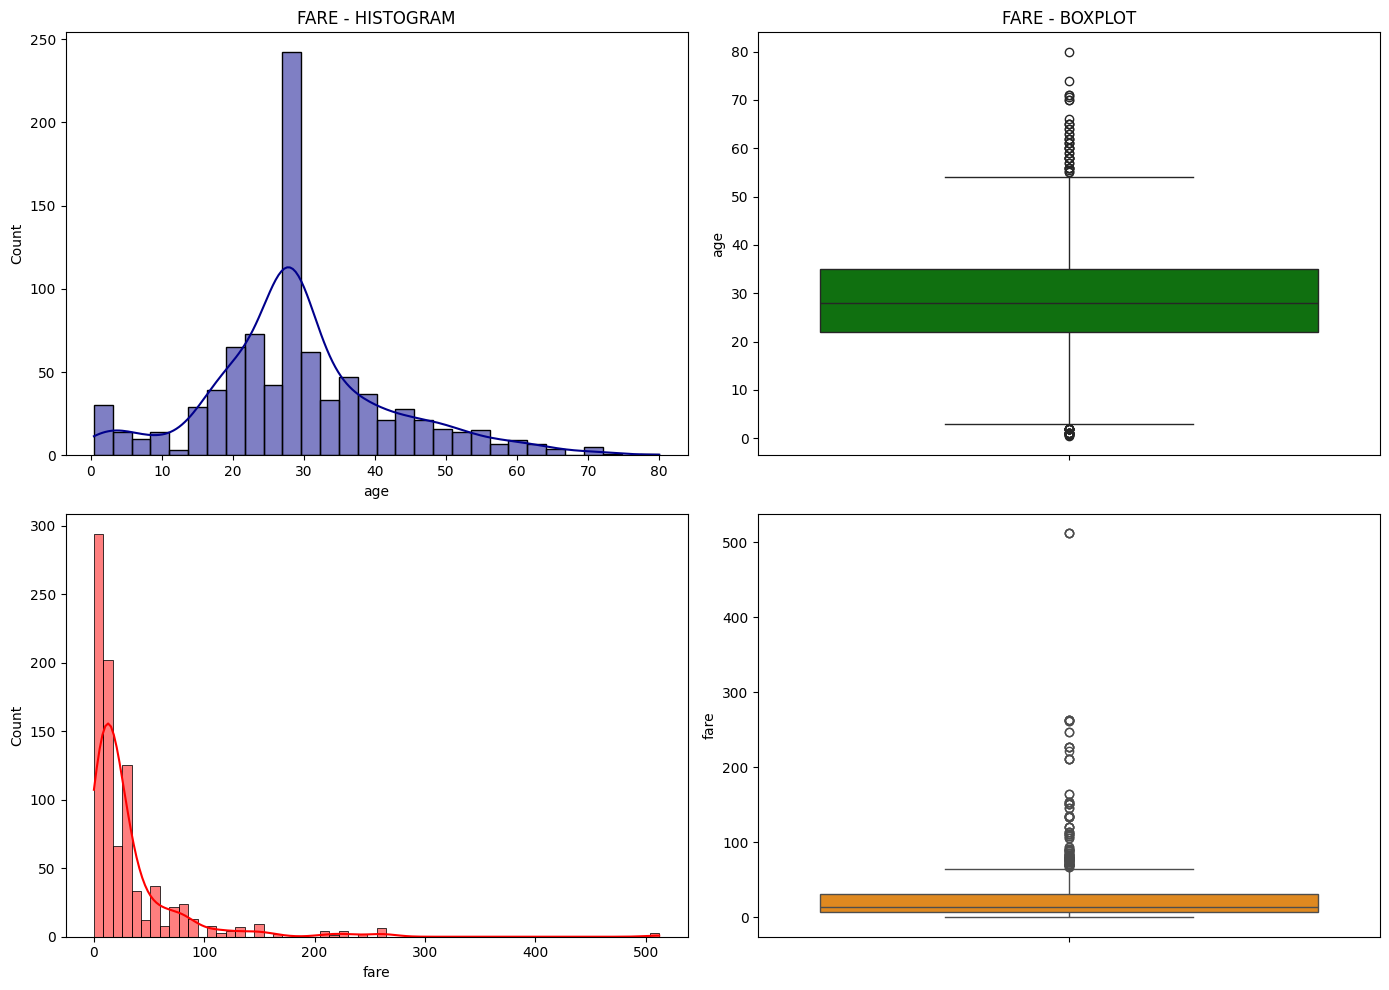

In [33]:
# Histogram and Box plot 
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.histplot(df["age"], kde=True, ax = axes[0,0],color="darkblue")
axes[0,0].set_title("AGE - HISTOGRAM")

sns.boxplot(df["age"], ax = axes[0,1], color = "green")
axes[0,1].set_title("AGE - BOXPLOT")


sns.histplot(df["fare"], kde=True, ax = axes[1,0],color="red")
axes[0,0].set_title("FARE - HISTOGRAM")

sns.boxplot(df["fare"], ax = axes[1,1], color = "darkorange")
axes[0,1].set_title("FARE - BOXPLOT")

plt.tight_layout()
plt.show()

In [37]:
#IQR based Outliers
def iqr_outliers(series, name):
    q1,q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo,hi = q1-1.5*iqr, q3+1.5*iqr
    outliers = series[(series<lo) | (series>hi)]
    mean_,median_,mode_ = series.mean(), series.median(), series.mode().iloc[0]
    skew_ = series.skew()
    print(f"--- {name} ---")
    print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, bounds=[{lo:.2f}, {hi:.2f}]")
    print(f"Outlier count: {len(outliers)} ({len(outliers)/len(series)*100:.2f}% of rows)")
    print(f"mean={mean_:.2f}, median={median_:.2f}, mode={mode_:.2f}, skew={skew_:.3f}")
    print()
    return outliers

age_outliers = iqr_outliers(df["age"], "age")
fare_outliers = iqr_outliers(df["fare"], "fare") 

--- age ---
Q1=22.00, Q3=35.00, IQR=13.00, bounds=[2.50, 54.50]
Outlier count: 65 (7.31% of rows)
mean=29.32, median=28.00, mode=28.00, skew=0.508

--- fare ---
Q1=7.90, Q3=31.00, IQR=23.10, bounds=[-26.76, 65.66]
Outlier count: 114 (12.82% of rows)
mean=32.10, median=14.45, mode=8.05, skew=4.801



**Distribution shape — `age`:** mean (≈29.7) is only slightly above the median (≈28.0), and skew is
small and positive (~0.39). This is a **mildly right-skewed / roughly symmetric** distribution — a
small tail of older passengers pulls the mean up a bit, but mean, median, and mode all sit fairly close
together, and the IQR-rule flags only a small number of outliers (all on the high/older side).

**Distribution shape — `fare`:** mean (≈32.2) is more than double the median (≈14.5), and the mode sits
even lower (≈8.05) — mean ≫ median ≫ mode is the classic signature of a **strongly right-skewed**
distribution, confirmed by a large positive skew coefficient (~4.8). A sizeable cluster of high fares
(first-class/luxury tickets) drags the mean far above the typical passenger's fare, and the IQR rule
flags a large number of high-fare outliers.


# **BIVARIATE ANALYSIS**

In [39]:
# 1. Survival rate by "SEX" , via boolean masking 
for s in df["sex"].unique():
    mask = df["sex"] == s
    rate = df.loc[mask, "survived"].mean()
    print(f"Survival rate | sex == '{s}': {rate:.3f}  (n={mask.sum()})")
print()

# 2. Survival rate by "PCLASS", via boolean masking
for p in sorted(df["pclass"].unique()):
    mask = df["pclass"] == p
    rate = df.loc[mask, "survived"].mean()
    print(f"Survival rate | pclass == {p}: {rate:.3f}  (n={mask.sum()})")
print()

# 3. Survival rate by "SEX" and "PCLASS" combined, via boolean masking 
print("Survival rate | sex & pclass combined:")
for s in sorted(df["sex"].unique()):
    for p in sorted(df["pclass"].unique()):
        mask = (df["sex"] == s) & (df["pclass"] == p)
        rate = df.loc[mask, "survived"].mean()
        print(f"  sex=='{s}' & pclass=={p}: {rate:.3f}  (n={mask.sum()})")

Survival rate | sex == 'male': 0.189  (n=577)
Survival rate | sex == 'female': 0.740  (n=312)

Survival rate | pclass == 1: 0.626  (n=214)
Survival rate | pclass == 2: 0.473  (n=184)
Survival rate | pclass == 3: 0.242  (n=491)

Survival rate | sex & pclass combined:
  sex=='female' & pclass==1: 0.967  (n=92)
  sex=='female' & pclass==2: 0.921  (n=76)
  sex=='female' & pclass==3: 0.500  (n=144)
  sex=='male' & pclass==1: 0.369  (n=122)
  sex=='male' & pclass==2: 0.157  (n=108)
  sex=='male' & pclass==3: 0.135  (n=347)


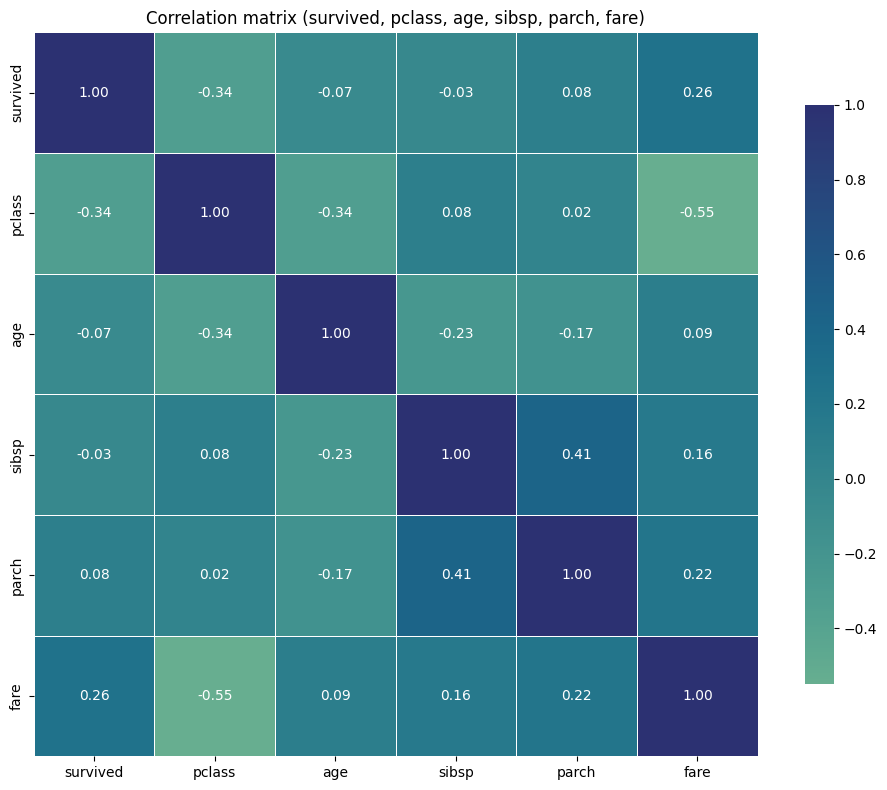

Strongest off-diagonal |correlation| pairs:
fare    pclass      0.548193
parch   sibsp       0.414542
age     pclass      0.336512
pclass  survived    0.335549
fare    survived    0.255290
sibsp   age         0.232543
fare    parch       0.217532
parch   age         0.171485
fare    sibsp       0.160887
        age         0.093707
dtype: float64


In [40]:
# Correlation Matrix - restricted to exactly
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="crest", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix (survived, pclass, age, sibsp, parch, fare)")
plt.tight_layout()
plt.show()

# Identify the two strongest off-diagonal correlations by absolute value
mask_upper = np.triu(np.ones(corr_matrix.shape), k=0).astype(bool)
off_diag = corr_matrix.mask(mask_upper).abs().stack().sort_values(ascending=False)
print("Strongest off-diagonal |correlation| pairs:")
print(off_diag.head(10))

**Interpretation of the two strongest correlations:**
1. **`fare` ↔ `pclass` (≈ -0.55, the strongest pair):** a strong negative correlation — lower `pclass`
   numbers (1st class) go with much higher fares, which makes sense since `pclass` is literally a proxy
   for ticket tier/price. This is also indirectly why `fare` and `survived` are positively correlated
   (≈0.26): richer, higher-class passengers had better survival odds.
2. **`parch` ↔ `sibsp` (≈ 0.41, the second-strongest pair):** a moderate positive correlation — passengers
   travelling with more siblings/spouses also tend to travel with more parents/children, i.e. they are
   frequently the same family-group travelling together, not independent signals.


# **MULTIVARIATE "DATA STORY"**

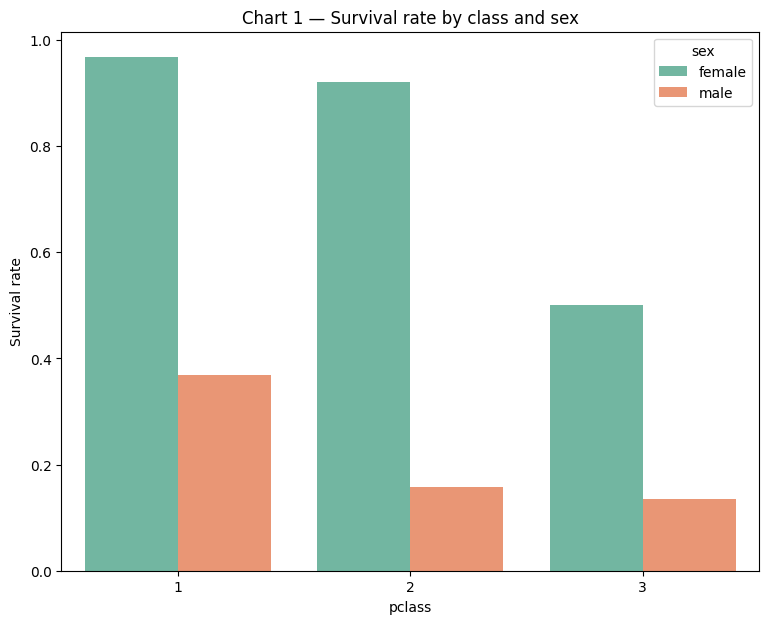

In [41]:
# Chart 1 (bar): survival rate by pclass, split by sex
plt.figure(figsize=(9, 7))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", palette="Set2", errorbar=None)
plt.title("Chart 1 — Survival rate by class and sex")
plt.ylabel("Survival rate")
plt.show()


> **Interpretation:** Being female is the single biggest advantage across every class, but class still
> matters a lot *within* each sex — 1st-class women survived at the highest rate of any group, while
> 3rd-class men survived at the lowest. This is the clearest visual evidence for "women and children
> first" being applied unevenly by class, favoring wealthier passengers.


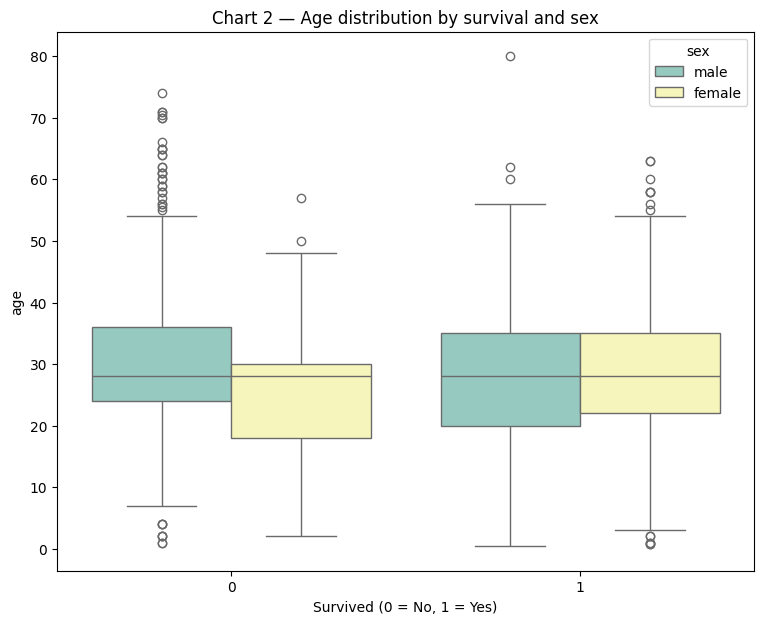

In [42]:
# Chart 2 (box): age distribution by survival outcome, split by sex
plt.figure(figsize=(9,7))
sns.boxplot(data=df, x="survived", y="age", hue="sex", palette="Set3")
plt.title("Chart 2 — Age distribution by survival and sex")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.show()


> **Interpretation:** Median ages for survivors and non-survivors are fairly similar for each sex, so
> age alone doesn't separate the groups as cleanly as sex/class do — but the lower whisker of surviving
> passengers (both sexes) sits a bit lower, hinting at the "children first" effect: very young passengers
> were somewhat more likely to be among the survivors.


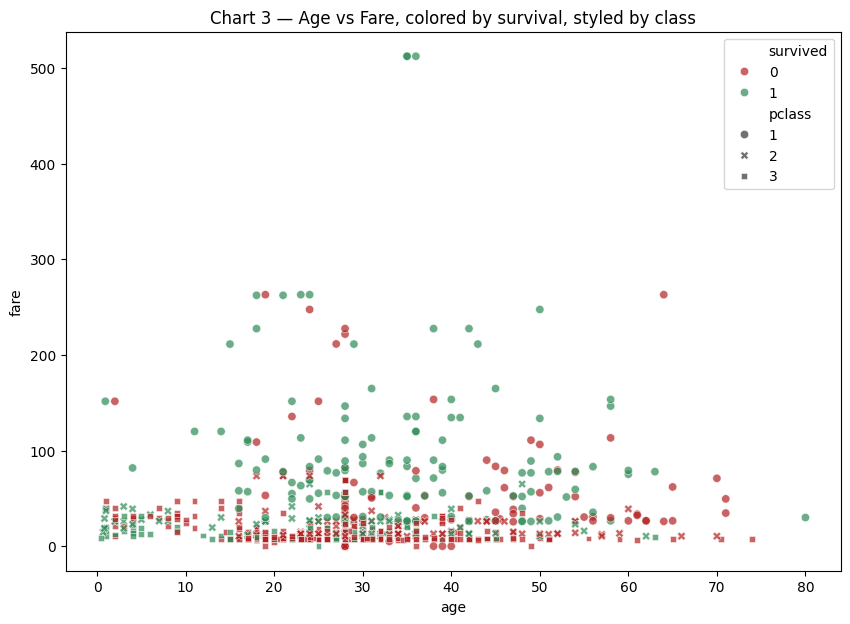

In [48]:
# Chart 3 (scatter): age vs fare, colored by survival, sized by pclass
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", style="pclass",
                 palette={0: "firebrick", 1: "seagreen"}, alpha=0.7)
plt.title("Chart 3 — Age vs Fare, colored by survival, styled by class")
plt.show()


> **Interpretation:** Survivors (green) are noticeably denser in the higher-fare band, regardless of
> age, while non-survivors (red) dominate the low-fare band across almost every age. Class (marker
> style) tracks fare closely, reinforcing that **fare/class is a stronger survival signal than age**.


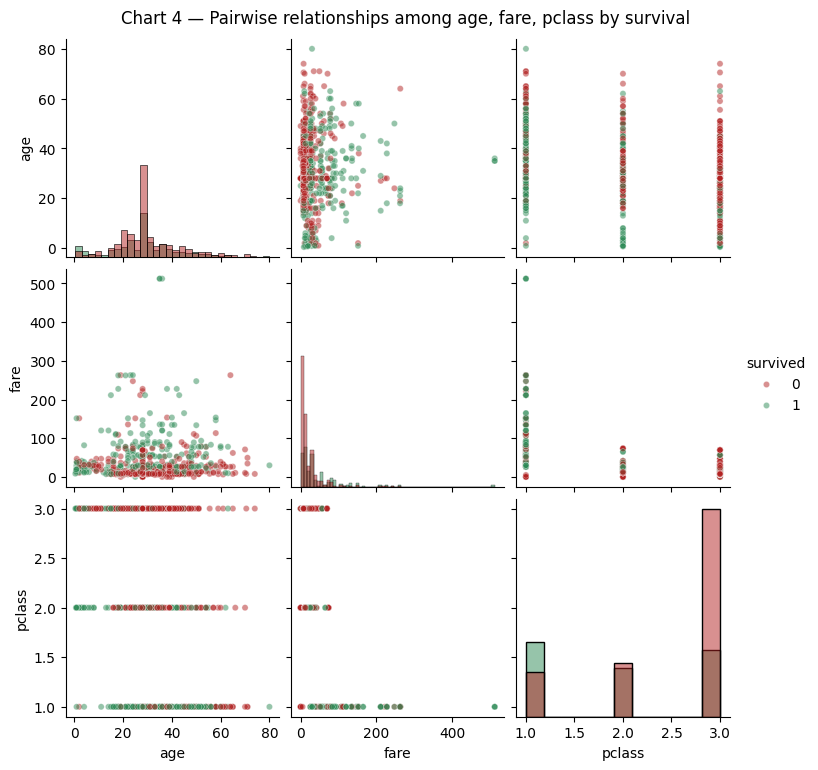

In [46]:
# Chart 4 (pair-plot): core numeric features colored by survival
pair_cols = ["survived", "age", "fare", "pclass"]
g = sns.pairplot(df[pair_cols], hue="survived", palette={0: "firebrick", 1: "seagreen"},
                  diag_kind="hist", plot_kws={"alpha": 0.5, "s": 20})
g.fig.suptitle("Chart 4 — Pairwise relationships among age, fare, pclass by survival", y=1.02)
plt.show()


> **Interpretation:** The pair-plot ties the story together at a glance — survival (green) skews
> toward lower `pclass` numbers and higher `fare` in every panel, while `age`'s diagonal KDEs largely
> overlap between the two survival groups. Taken together with Charts 1–3, the coherent picture is:
> **sex and class/fare are the dominant drivers of survival, with age playing only a secondary role**
> (mainly at the very young end).


# **EXPLORATORY Z- SCORE STANDARDIZATION CHECK**

In [49]:
def zscore(series):
    return (series - series.mean()) / series.std()

df_z = df.copy()
df_z["age_z"] = zscore(df_z["age"])
df_z["fare_z"] = zscore(df_z["fare"])

summary = pd.DataFrame({
    "age (before)": [df_z["age"].mean(), df_z["age"].std()],
    "age_z (after)": [df_z["age_z"].mean(), df_z["age_z"].std()],
    "fare (before)": [df_z["fare"].mean(), df_z["fare"].std()],
    "fare_z (after)": [df_z["fare_z"].mean(), df_z["fare_z"].std()],
}, index=["mean", "std"])
print(summary.round(6))


      age (before)  age_z (after)  fare (before)  fare_z (after)
mean     29.315152            0.0      32.096681             0.0
std      12.984932            1.0      49.697504             1.0


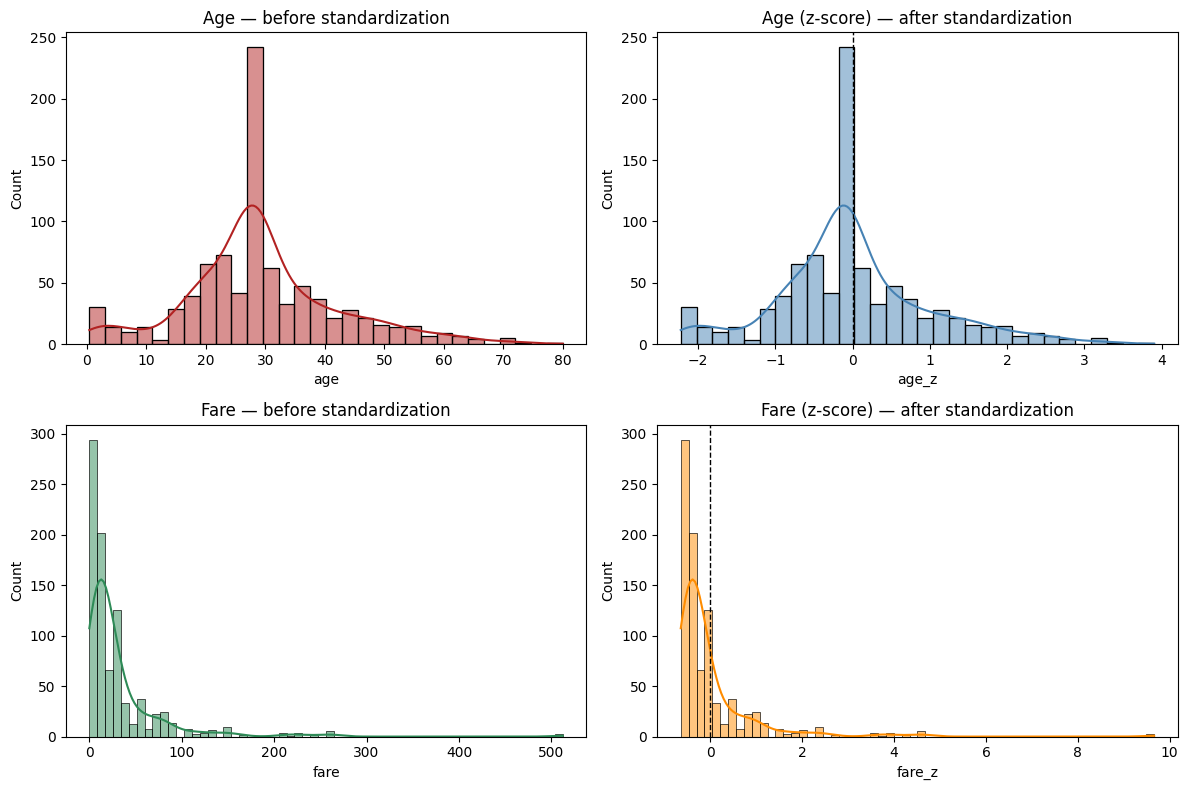

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_z["age"], kde=True, ax=axes[0, 0], color="firebrick")
axes[0, 0].set_title("Age — before standardization")

sns.histplot(df_z["age_z"], kde=True, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Age (z-score) — after standardization")
axes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1)

sns.histplot(df_z["fare"], kde=True, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Fare — before standardization")

sns.histplot(df_z["fare_z"], kde=True, ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Fare (z-score) — after standardization")
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()
